# CS319 Data Science Programming Graduate Project: Analyzing Airline Fare Fluctuations and Consumer Insights
---

By Ting-Yu Hu (Anita Hu)

## 📌 Objectives of The Project

#### **Purpose of the Analysis**  
The purpose of this analysis is to understand the reasons behind airline fare fluctuations, especially how high-priced and low-priced airlines adjust their prices under different circumstances. By doing this analysis, we can find out:

1. **How Airlines Adjust Fares**  
We get to understand how high-priced airlines (like UA, AA) and low-priced airlines (such as G4, F9) change their fares based on demand, and how they were affected by the pandemic.
2. **Fare Trends**  
We explore how fares were lower in 2020 and 2021, then how they changed afterward, as well as which quarters had the highest or lowest fares. This information helps us predict future fare trends.
3. **Factors Affecting Fares**  
We analyze how different seasons and market demand affect ticket prices, especially the impact of unexpected events like the pandemic.
4. **What Consumers Can Learn**  
For regular flyers, these insights can help you find the best time to buy tickets and choose the right airline.

---

## 🔗 Fetching the Data from API
***Data Sourse: https://data.transportation.gov/Aviation/Consumer-Airfare-Report-Table-5-Detailed-Fare-Info/bkh6-tj42/about_data***

In [8]:
import urllib.request as request
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
url = 'https://data.transportation.gov/resource/bkh6-tj42.json?$limit=50000'

# Use urllib.request.urlopen() to open the specified URL and read its response
with request.urlopen(url) as response:
    # Parse the response content into a JSON data structure and store it in the 'dataset' variable
    dataset = json.load(response)

---

## 🔃 Converting Data Format

In [12]:
# Convert the JSON data (dataset) into a Pandas DataFrame
df = pd.DataFrame(dataset)
df.head()

,tbl,year,quarter,mkt_fare,citymarketid_1,citymarketid_2,city1,city2,carairlineid,car,...,fareinc_min,fareinc_minpaxsh,fareinc_max,fare_inc_maxpaxsh,fare_inc_x3paxsh,cityname_location1,cityname_location1_city,cityname_location2,cityname_location2_city,tbl5pk
0,Table 5,2006,3,87.41,34057,31884,"Portland, OR","Spokane, WA",19393,WN,...,75,0.44,125,0.25,0,"{'type': 'Point', 'coordinates': [-122.681425,...","Portland, OR","{'type': 'Point', 'coordinates': [-117.425022,...","Spokane, WA",20063340573188419393WN
1,Table 5,1997,4,224.47,30721,30198,"Boston, MA (Metropolitan Area)","Pittsburgh, PA",20355,US,...,75,0.07,400,0.25,0.42,"{'type': 'Point', 'coordinates': [-71.056742, ...","Boston, MA (Metropolitan Area)","{'type': 'Point', 'coordinates': [-79.994945, ...","Pittsburgh, PA",19974307213019820355US
2,Table 5,2003,1,234.32,31995,30852,"Greensboro/High Point, NC","Washington, DC (Metropolitan Area)",20355,US,...,100,0.15,375,0.11,0.32,"{'type': 'Point', 'coordinates': [-79.793899, ...","Greensboro/High Point, NC","{'type': 'Point', 'coordinates': [-77.019912, ...","Washington, DC (Metropolitan Area)",20031319953085220355US
3,Table 5,1998,3,71.25,32467,33195,"Miami, FL (Metropolitan Area)","Tampa, FL (Metropolitan Area)",19393,WN,...,75,0.99,75,0.99,0,"{'type': 'Point', 'coordinates': [-93.264346, ...","Miami, FL (Metropolitan Area)","{'type': 'Point', 'coordinates': [-78.804199, ...","Tampa, FL (Metropolitan Area)",19983324673319519393WN
4,Table 5,1999,3,235.25,30713,30325,"Boise, ID","Denver, CO",19977,UA,...,125,0.09,550,0.06,0.18,"{'type': 'Point', 'coordinates': [-83.884521, ...","Boise, ID","{'type': 'Point', 'coordinates': [-104.984853,...","Denver, CO",19993307133032519977UA


***Column Names and Descriptions of The Original Dataset***
- `tbl`: Name of the data table.
- `Year`: Year.
- `quarter`: Quarter.
- `mkt_fare`: The average fare for the route for the airline.
- `citymarketid_1`: The city market ID identifying the market of the first city.
- `citymarketid_2`: The city market ID identifying the market of the second city.
- `city1`: The name and state of the first city.
- `city2`: The name and state of the second city.
- `carairlineid`: The airline ID identifying the airline operating the flight.
- `car`: The airline code identifying the airline.
- `carpax`: The number of passengers carried by the airline on the route.
- `carpaxshare`: The market share of the airline on a specific route.
- `caravgfare`: Carrier’s average fare for the route.
- `fareinc_min`: The smallest fare change.
- `fareinc_minpaxsh`: The share of passengers paying the minimum fare increase.
- `fareinc_max`: The largest fare change.
- `fareinc_maxpaxsh`: The share of passengers paying the maximum fare increase.
- `fare_inc_x3paxsh`: The percentage of passengers paying three times minimum fare.
- `cityname_location1`: City with Latitude and Longitude for city1.
- `cityname_location2`: City with Latitude and Longitude for city2.
- `tbl5pk`: The unique primary key of the dataset, identifying each record.

---

## 🧹 Cleaning the Data

In [16]:
# Drop unnecessary columns
df.drop(columns=['tbl', 'citymarketid_1', 'citymarketid_2', 'cityname_location1', 'cityname_location1_city', 'cityname_location2', 'cityname_location2_city', 'tbl5pk'], inplace=True)

In [17]:
# Convert data type
df[['mkt_fare', 'carpax', 'carpaxshare', 'caravgfare', 'fareinc_minpaxsh', 'fare_inc_maxpaxsh', 'fare_inc_x3paxsh']] = df[['mkt_fare', 'carpax', 'carpaxshare', 'caravgfare', 'fareinc_minpaxsh', 'fare_inc_maxpaxsh', 'fare_inc_x3paxsh']].apply(pd.to_numeric, errors='coerce')

In [18]:
# Filter the DataFrame to the 'year' column is between 2010 and 2024 (inclusive)
df = df[df['year'].astype(int).between(2000, 2024)]

In [19]:
# Delete rows where carairlineid is -1
df = df[df['carairlineid'] != -1]

In [20]:
# Delete rows where car has missing data from 2000 to 2024
df = df[~df['car'].isin(['3M', 'B6', 'CO', 'DL', 'FL', 'MX', 'NW', 'SY', 'US', 'WN', 'XP', 'DH', 'HP', 'QX', 'SX', 'TZ', 'VX', 'YX', 'JI', 'RP', 'TW', 'NK'])]

In [21]:
df.head()

,year,quarter,mkt_fare,city1,city2,carairlineid,car,carpax,carpaxshare,caravgfare,fareinc_min,fareinc_minpaxsh,fareinc_max,fare_inc_maxpaxsh,fare_inc_x3paxsh
5,2006,3,235.98,"Chicago, IL","Greensboro/High Point, NC",19977,UA,12170,0.77,239.12,100,0.05,350,0.08,0.270000
11,2013,2,264.17,"Chicago, IL","Harrisburg, PA",19977,UA,8910,0.55,264.46,225,0.27,375,0.07,0.001122
14,2010,1,268.79,"Huntsville, AL","Washington, DC (Metropolitan Area)",19977,UA,4220,0.13,317.55,150,0.06,450,0.11,0.220000
16,2010,2,226.22,"Syracuse, NY","Washington, DC (Metropolitan Area)",19977,UA,3580,0.16,281.51,75,0.05,400,0.05,0.660000
20,2008,2,239.95,"Chicago, IL","Greensboro/High Point, NC",19977,UA,13150,0.74,252.92,100,0.06,325,0.10,0.260000


In [22]:
df.describe()

,mkt_fare,carpax,carpaxshare,caravgfare,fareinc_minpaxsh,fare_inc_maxpaxsh,fare_inc_x3paxsh
count,3628.000000,3628.000000,3628.000000,3628.000000,3628.000000,3628.000000,3628.000000
mean,202.685449,13509.581036,0.332801,204.933166,0.191700,0.097633,0.123581
std,87.855662,14733.283516,0.182040,90.789559,0.153764,0.063311,0.145559
min,71.380000,330.000000,0.100000,69.250000,0.050000,0.050000,0.000000
25%,109.889548,5747.500000,0.180932,108.850000,0.070785,0.060000,0.020000
50%,229.925000,9625.000000,0.300000,221.475031,0.120400,0.076050,0.054206
75%,273.750000,14925.000000,0.444603,281.060370,0.280000,0.110000,0.196268
max,407.360000,312730.000000,1.000000,530.620000,0.790000,0.560000,0.743008


In [23]:
missing_data = df.isnull().sum()
missing_data

year                 0
quarter              0
mkt_fare             0
city1                0
city2                0
carairlineid         0
car                  0
carpax               0
carpaxshare          0
caravgfare           0
fareinc_min          0
fareinc_minpaxsh     0
fareinc_max          0
fare_inc_maxpaxsh    0
fare_inc_x3paxsh     0
dtype: int64

In [24]:
num_duplicates = df.duplicated().sum()
num_duplicates

0

---

## 📥 Creating new Columns

In [27]:
# Create the 'price_Category' column based on the specified ranges
mean_price = df['caravgfare'].mean()
std_dev_price = df['caravgfare'].std()

# Function to classify price as Low, Medium, or High based on mean and std dev
def classify_price(price):
    if price <= mean_price - std_dev_price:
        return 'Low'
    elif price <= mean_price + std_dev_price:
        return 'Medium'
    else:
        return 'High'

# Add a new column 'price_category' based on caravgfare
df['price_category'] = df['caravgfare'].apply(classify_price)

In [28]:
#Create the 'demand_level' column based on the specified ranges
df['demand_level'] = pd.cut(df['carpaxshare'], bins = [0, 0.2, 0.4, 1], labels = ['Low', 'Medium', 'High'], include_lowest=True)

In [29]:
df.head()

,year,quarter,mkt_fare,city1,city2,carairlineid,car,carpax,carpaxshare,caravgfare,fareinc_min,fareinc_minpaxsh,fareinc_max,fare_inc_maxpaxsh,fare_inc_x3paxsh,price_category,demand_level
5,2006,3,235.98,"Chicago, IL","Greensboro/High Point, NC",19977,UA,12170,0.77,239.12,100,0.05,350,0.08,0.270000,Medium,High
11,2013,2,264.17,"Chicago, IL","Harrisburg, PA",19977,UA,8910,0.55,264.46,225,0.27,375,0.07,0.001122,Medium,High
14,2010,1,268.79,"Huntsville, AL","Washington, DC (Metropolitan Area)",19977,UA,4220,0.13,317.55,150,0.06,450,0.11,0.220000,High,Low
16,2010,2,226.22,"Syracuse, NY","Washington, DC (Metropolitan Area)",19977,UA,3580,0.16,281.51,75,0.05,400,0.05,0.660000,Medium,Low
20,2008,2,239.95,"Chicago, IL","Greensboro/High Point, NC",19977,UA,13150,0.74,252.92,100,0.06,325,0.10,0.260000,Medium,High


---

## 🔎 Data Overview

#### ***Q1: What is the total row number and column number?***

In [33]:
row_num = df.shape[0]
col_num = df.shape[1]
print(f"The total row number is {row_num}\nThe total column number is {col_num}")

The total row number is 3628
The total column number is 17


#### ***Q2: What are the columns after data cleaning?***

In [35]:
df.columns

Index(['year', 'quarter', 'mkt_fare', 'city1', 'city2', 'carairlineid', 'car',
       'carpax', 'carpaxshare', 'caravgfare', 'fareinc_min',
       'fareinc_minpaxsh', 'fareinc_max', 'fare_inc_maxpaxsh',
       'fare_inc_x3paxsh', 'price_category', 'demand_level'],
      dtype='object')

***Column Names and Descriptions of The Cleaned Dataset***
- `Year`: Year.
- `quarter`: Quarter.
- `mkt_fare`: The average fare for the route for the airline.
- `city1`: The name and state of the first city.
- `city2`: The name and state of the second city.
- `carairlineid`: The airline ID identifying the airline operating the flight.
- `car`: The airline code identifying the airline.
- `carpax`: The number of passengers carried by the airline on the route.
- `carpaxshare`: The market share of the airline on a specific route.
- `caravgfare`: Carrier’s average fare for the route.
- `fareinc_min`: The smallest fare change.
- `fareinc_minpaxsh`: The share of passengers paying the minimum fare increase.
- `fareinc_max`: The largest fare change.
- `fareinc_maxpaxsh`: The share of passengers paying the maximum fare increase.
- `fare_inc_x3paxsh`: The percentage of passengers paying three times minimum fare.
- `price_category`: **Derived Column**, Fare category (e.g., Low, Medium, High fare levels).
- `demand_level`: **Derived Column**, Demand level for the flight (e.g., High, Medium, Low demand).

#### ***Q3: Which flights are included?***

In [38]:
df['car'].unique()

array(['UA', 'AA', 'F9', 'G4', 'AS'], dtype=object)

- `AA`: American Airlines.
- `AS`: Alaska Airlines .
- `F9`: Frontier Airlines.
- `G4`: Allegiant Air.
- `UA`: United Airlines.

#### ***Q4: What is the time period of the dataset?***

In [41]:
min_year = df['year'].astype(int).min()
max_year = df['year'].astype(int).max()
print(f"The dataset time period is from {min_year} to {max_year}")

The dataset time period is from 2000 to 2024


---

## 🎨 Data Visualization

#### ***Q5: What is the distribution of the flight fare?***  
💡 The distribution of flight fares is bimodal (double-peaked), indicating the presence of two main fare ranges. This suggests that the airlines can be divided into two distinct groups:  
1. One group of airlines sells relatively lower fares, likely corresponding to low-cost carriers or budget-friendly options.  
2. Another group of airlines sells higher fares, which may be related to premium services or full-service airlines offering more benefits and flexibility.

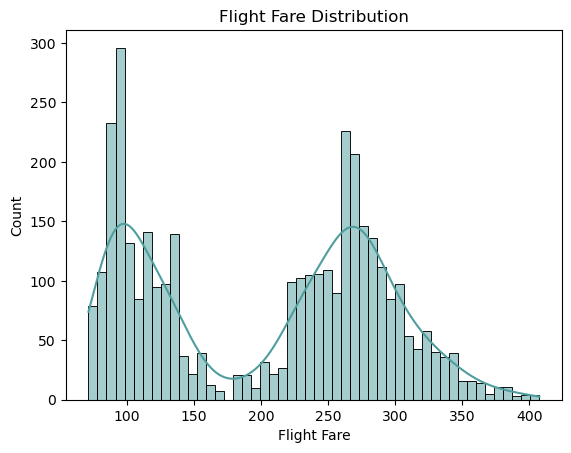

count    3628.000000
mean      202.685449
std        87.855662
min        71.380000
25%       109.889548
50%       229.925000
75%       273.750000
max       407.360000
Name: mkt_fare, dtype: float64

In [45]:
sns.histplot(df['mkt_fare'], bins=50, kde=True, color='#4F9D9D')
plt.title("Flight Fare Distribution")
plt.xlabel("Flight Fare")
plt.show()
df['mkt_fare'].describe()

#### ***Q6: What is the trend of average flight fare changes across quarters from 2000 to 2024?***

*Conclusion:*  
**Quarter 1 and Quarter 2**:  
Fares were relatively higher.  
Minimal difference between Q1 and Q2, making them the highest quarters for average fares.  
**Quarter 3**:  
Fares were slightly lower than Q1 and Q2, showing a decline in fares.  
**Quarter 4**:  
Fares were the lowest of all four quarters.

In [47]:
# Group by 'quarter' and calculate the mean of 'mkt_fare' for each quarter
# Use reset_index() to reset the index and turn the result into a regular DataFrame
df_quarter_avg = df.groupby('quarter')['mkt_fare'].mean().reset_index()

# Rename the columns of the "df_quarter_avg" to 'Quarter' and 'Average_Fare_2000_2024'
df_quarter_avg.columns = ['Quarter', 'Average Fare']
diff = df_quarter_avg['Average Fare'].max() - df_quarter_avg['Average Fare'].min()
print(f"The average fare difference across Q1 to Q4 is {diff}")
df_quarter_avg

The average fare difference across Q1 to Q4 is 13.577035056238458


,Quarter,Average Fare
0,1,207.779350
1,2,207.215418
2,3,200.340448
3,4,194.202314


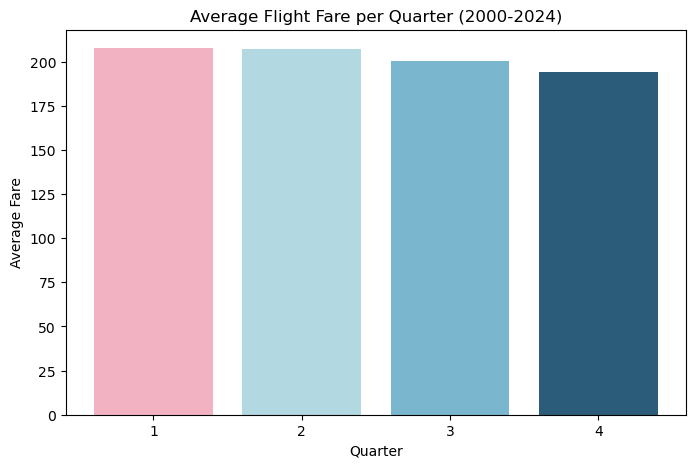

In [48]:
# Plot the quarterly fare using a bar chart
plt.figure(figsize=(8, 5))
plt.bar(df_quarter_avg['Quarter'], df_quarter_avg['Average Fare'], color= ['#f2b2c2', '#b2d9e1', '#7bb6cf', '#2b5c7a'])

plt.xlabel('Quarter')
plt.ylabel('Average Fare')
plt.title('Average Flight Fare per Quarter (2000-2024)')
plt.xticks(df_quarter_avg['Quarter'])
plt.show()

#### ***Q7: What is the trend of flight fare changes across years?***

*Conclusion:*  
**2008 to 2009**: The fare dropped sharply due to the **global financial crisis**, which caused a dramatic decrease in demand. Airlines had to lower prices to attract passengers.  
**2014 to 2016**: Fares peaked, driven by the **global economic recovery**, **rising fuel prices**, and strong **travel demand**. Airlines increased prices to cope with the rise in demand and operating costs.  
**2020 to 2021**: Fares significantly decreased due to the **COVID-19 pandemic**, which caused a massive drop in global air travel demand. Airlines significantly reduced prices to cope with travel restrictions and a sharp decline in demand.  
**2021 to 2024**: Fares gradually increased as the **pandemic eased** and global markets began recovering. Air travel demand rose, and airlines raised prices to accommodate the growth in demand.

In [50]:
# Group by 'year' and calculate the mean of 'mkt_fare' for each quarter
# Use reset_index() to reset the index and turn the result into a regular DataFrame
df_year_avg = df.groupby('year')['mkt_fare'].mean().reset_index()

# Rename the columns of the "df_year_avg" to 'Year' and 'Average_Fare_2000_2024'
df_year_avg.columns = ['Year', 'Average Fare']
df_year_avg

,Year,Average Fare
0,2000,220.824160
1,2001,211.609040
2,2002,196.470000
3,2003,176.097333
4,2004,135.904074
5,2005,133.691379
6,2006,163.369412
7,2007,174.194106
8,2008,225.070573
9,2009,154.501023


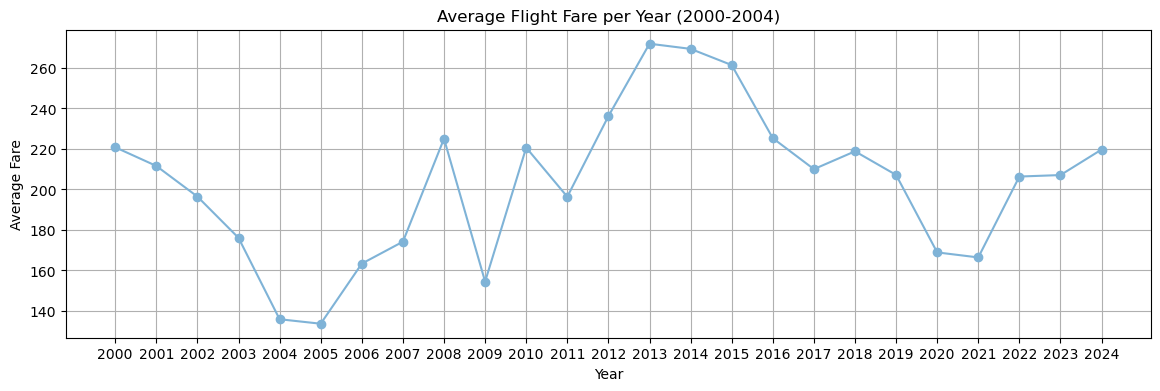

In [51]:
plt.figure(figsize=(14, 4))  
plt.plot(df_year_avg['Year'], df_year_avg['Average Fare'], color = '#7fb3d7', marker='o')  

plt.xlabel('Year')
plt.ylabel('Average Fare')
plt.title('Average Flight Fare per Year (2000-2004)')  
plt.xticks(df_year_avg['Year'])

# Enable the grid
plt.grid(True)
plt.show()

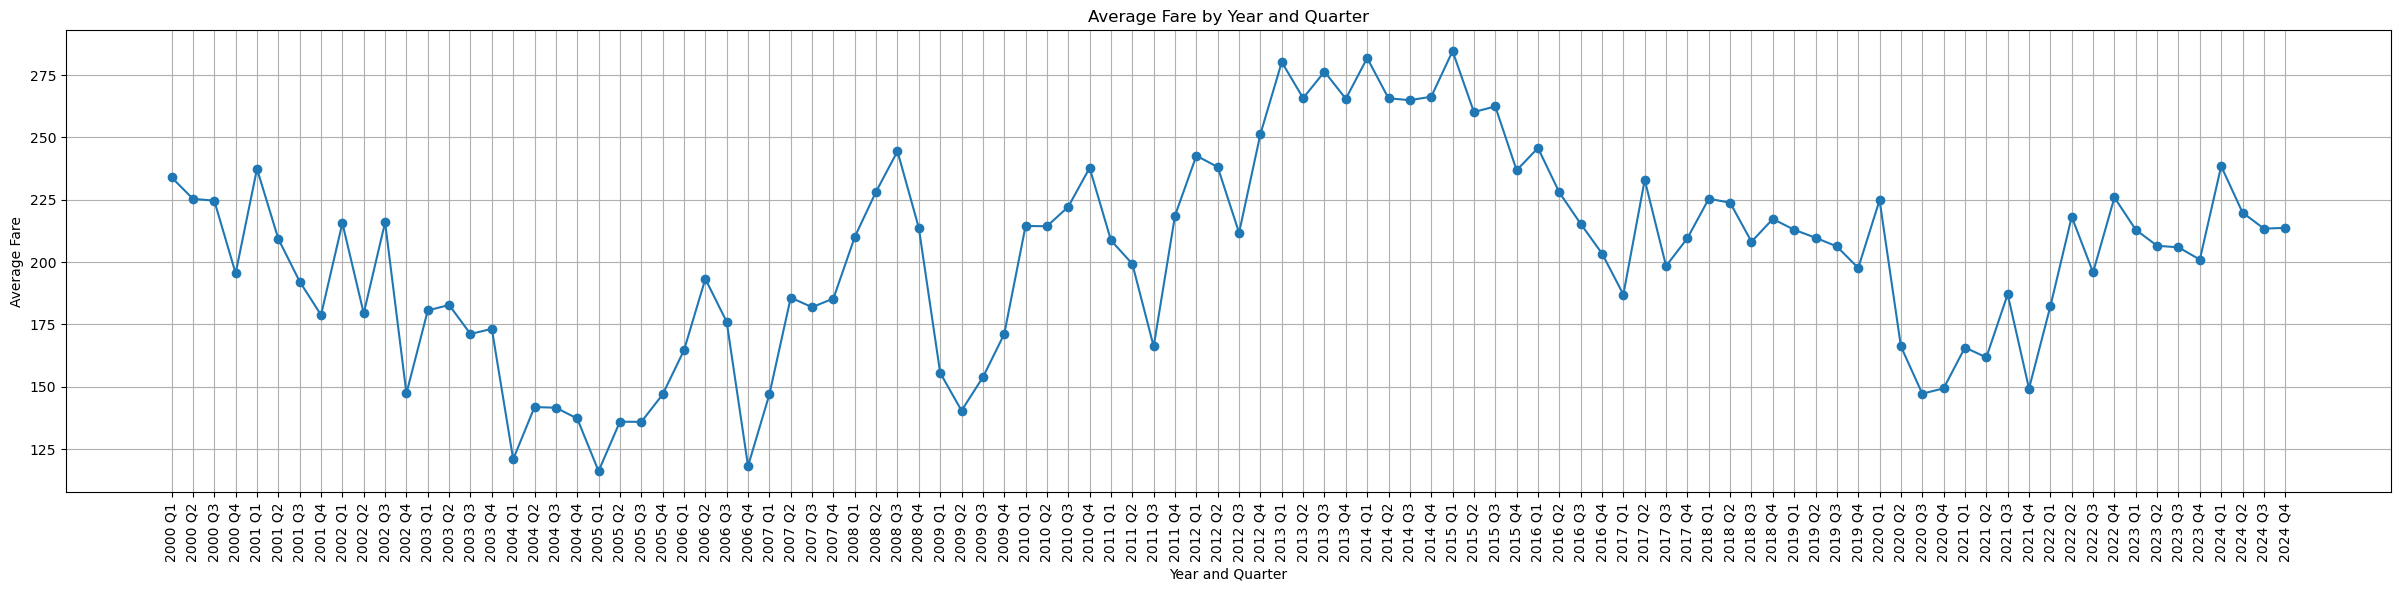

In [52]:
# Group by 'year' and 'quarter' and calculate the mean of 'mkt_fare' for each group
df_year_quarter_avg = df.groupby(['year', 'quarter'])['mkt_fare'].mean().reset_index()

# Rename the columns of the "df_year_quarter_avg" to 'Year and Quarter', 'Quarter', and 'Average_Fare_2000_2024_Q1_Q4'
df_year_quarter_avg.columns = ['Year', 'Quarter', 'Average Fare']

# Combine Year and Quarter into a single column to be used for the x-axis
df_year_quarter_avg['Year_Quarter'] = df_year_quarter_avg['Year'].astype(str) + ' Q' + df_year_quarter_avg['Quarter'].astype(str)

# Plotting the average fare by Year and Quarter
plt.figure(figsize=(30, 6))
plt.plot(df_year_quarter_avg['Year_Quarter'], df_year_quarter_avg['Average Fare'], marker='o')

plt.xlabel('Year and Quarter')
plt.ylabel('Average Fare')
plt.title('Average Fare by Year and Quarter')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

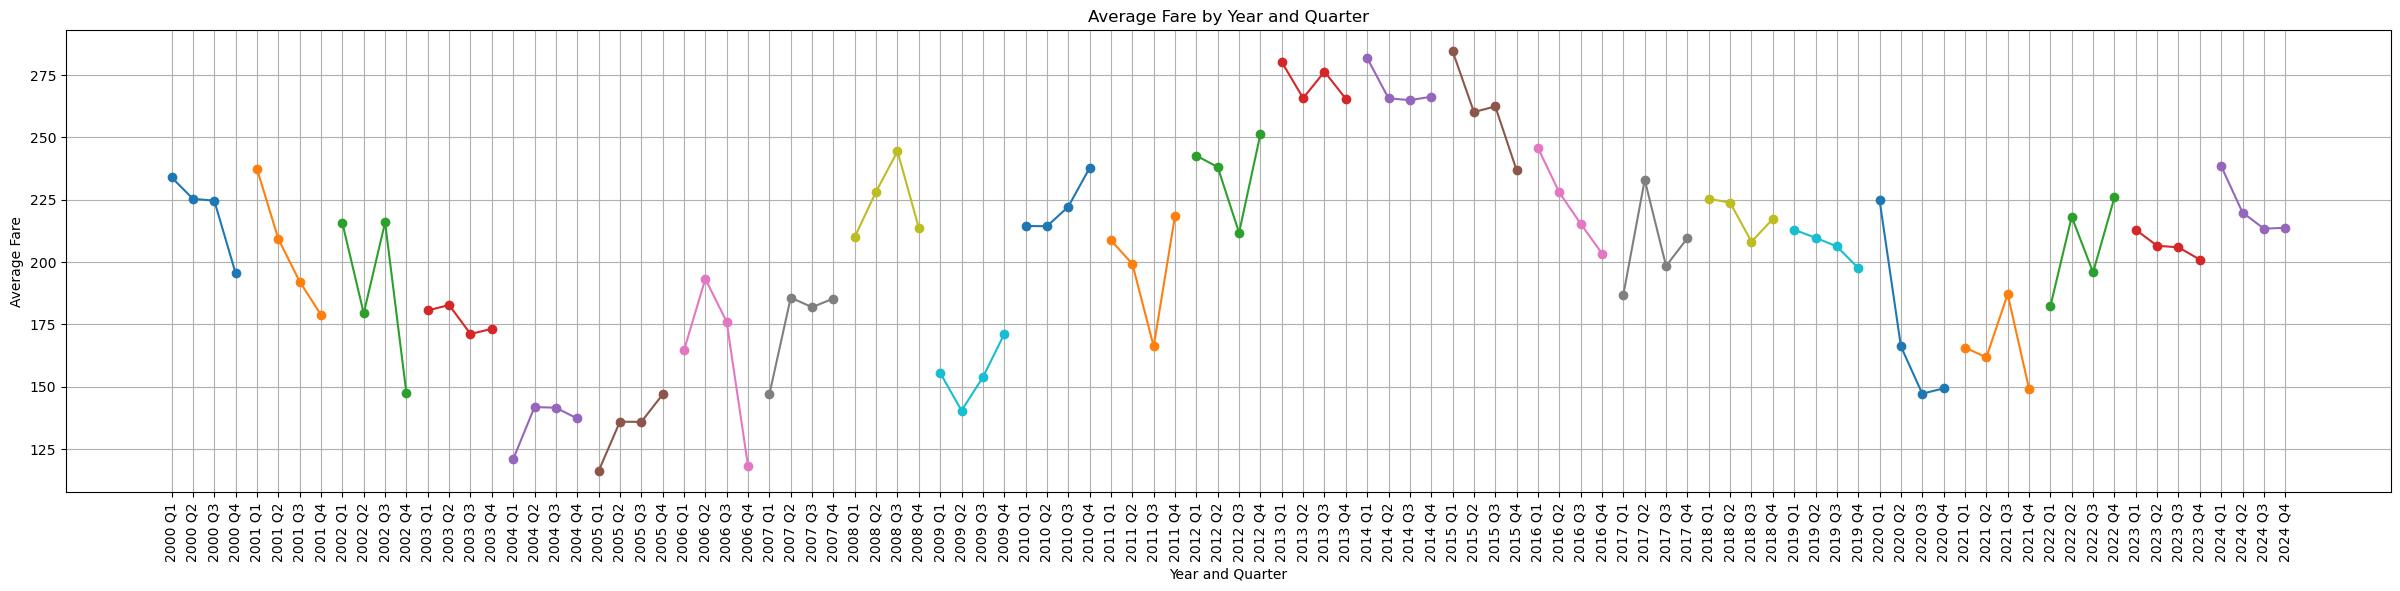

In [53]:
# Plotting the average fare by Year and Quarter with different colors for each year
plt.figure(figsize=(30, 6))

# Loop through each unique year and plot with a different color
for year in df_year_quarter_avg['Year'].unique():
    subset = df_year_quarter_avg[df_year_quarter_avg['Year'] == year]
    plt.plot(subset['Year_Quarter'], subset['Average Fare'], marker='o', label=f"Year {year}")

plt.xlabel('Year and Quarter')
plt.ylabel('Average Fare')
plt.title('Average Fare by Year and Quarter')

plt.xticks(rotation=90)
plt.grid(True)
plt.show()

#### ***Q8: What are the top 10 most frequent routes during the COVID-19 period in 2020 and 2021?***  

In [55]:
# Filter the data for the years 2020 and 2021
df_2020_2021 = df[(df['year'].astype(int) == 2020) | (df['year'].astype(int) == 2021)]

# Group by 'city1' and 'city2' to get the count of each route
route_group = df_2020_2021.groupby(['city1', 'city2'])

# Calculate the count of occurrences for each route
route_counts = route_group.size().reset_index(name='count')

# Sort the routes by 'count' in descending order to find the most frequent route
route_counts_sorted = route_counts.sort_values(by='count', ascending=False)

# Display the top route(s) with the highest occurrences
route_counts_sorted.head(10)

,city1,city2,count
98,"Huntsville, AL","Washington, DC (Metropolitan Area)",12
35,"Charlotte, NC","Hartford, CT",8
101,"Indianapolis, IN","Philadelphia, PA",8
107,"Knoxville, TN","Tampa, FL (Metropolitan Area)",8
91,"Fresno, CA","Las Vegas, NV",7
109,"Las Vegas, NV","Stockton, CA",7
19,"Boise, ID","Seattle, WA",6
58,"Cincinnati, OH","Valparaiso, FL",6
113,"Louisville, KY","New York City, NY (Metropolitan Area)",6
36,"Charlotte, NC","Indianapolis, IN",6


#### ***Q9: Which airlines operate the top 10 most expensive flight routes in 2024?***

*Conclusion:*  
*Most of the high-priced routes* in 2024 are operated by **United Airlines (UA)** and **American Airlines (AA)**.

In [57]:
# Filter the data for the years 2024
df_2024 = df[df['year'].astype(int) == 2024]

# Calculate the average fare by route (city1 -> city2)
df_route_avg_2024 = df_2024.groupby(['city1', 'city2', 'car'])['mkt_fare'].mean().reset_index()

# Sort the results by 'Average Fare'
df_route_avg_sorted_2024 = df_route_avg_2024.sort_values(by='mkt_fare', ascending=False)

# Get the top 10 most expensive routes
df_route_avg_sorted_2024.head(10)

,city1,city2,car,mkt_fare
3,"Aspen, CO","Los Angeles, CA (Metropolitan Area)",UA,357.787352
4,"Atlanta, GA (Metropolitan Area)","Charlotte, NC",AA,318.494480
21,"Charlotte, NC","Columbus, OH",AA,314.651342
44,"Cincinnati, OH","Philadelphia, PA",AA,308.118481
52,"Columbus, OH","Philadelphia, PA",AA,308.108832
73,"Indianapolis, IN","Philadelphia, PA",AA,303.809164
72,"Huntsville, AL","Washington, DC (Metropolitan Area)",UA,297.755122
71,"Huntsville, AL","Washington, DC (Metropolitan Area)",AA,297.755122
56,"Dayton, OH","Washington, DC (Metropolitan Area)",UA,296.953856
31,"Charlotte, NC","West Palm Beach/Palm Beach, FL",AA,296.292284


#### ***Q10: What is the highest-priced flight routes in 2024, and how has the fare for this route changed from 2020 to 2024?***  

*Conclusion:*  
The fare changes for the route from Aspen, CO to Los Angeles, CA show that in 2021, the pandemic caused a significant drop in fares to around 260. Following this, demand increased, and fares rebounded, reaching a peak of 390 in 2023. Aside from the pandemic impact, the fare remained above 300 during this period.

In [59]:
# Filter the data for the year 2020-2024, specific route (Aspen, CO -> Los Angeles, CA), and airline 'UA'
df_2020_2024_ua_route = df[(df['year'].astype(int).isin([2020, 2021, 2022, 2023, 2024])) &
                            (df['city1'] == 'Aspen, CO') &
                            (df['city2'] == 'Los Angeles, CA (Metropolitan Area)') &
                            (df['car'] == 'UA')]

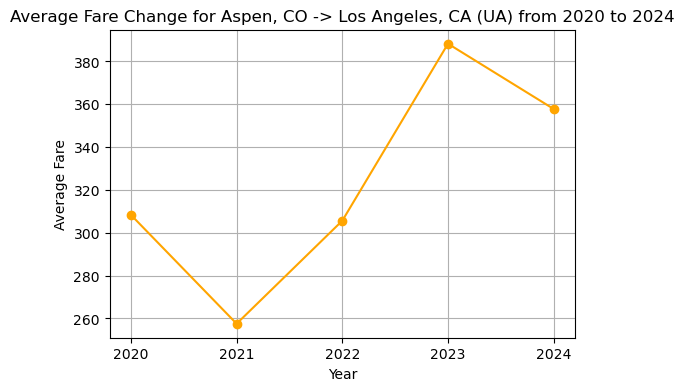

In [60]:
plt.figure(figsize=(6, 4))
plt.plot(df_2020_2024_ua_route['year'], df_2020_2024_ua_route['mkt_fare'], marker='o', color='orange')

plt.xlabel('Year')
plt.ylabel('Average Fare')
plt.title('Average Fare Change for Aspen, CO -> Los Angeles, CA (UA) from 2020 to 2024')

plt.grid(True)
plt.show()

#### ***Q11: Which airlines operate the top 10 cheapest flight routes in 2024?***

*Conclusion:*  
Most of the cheapest routes are operated by **G4 (Allegiant Airlines)**, with a few operated by **United Airlines (UA)**.

In [62]:
df_route_avg_sorted_2024.tail(10).sort_values(by = 'mkt_fare')

,city1,city2,car,mkt_fare
97,"Phoenix, AZ","Provo, UT",G4,88.901450
76,"Knoxville, TN","Sanford, FL",G4,93.326780
81,"Los Angeles, CA (Metropolitan Area)","Provo, UT",G4,94.877552
45,"Cincinnati, OH","Valparaiso, FL",G4,110.813142
94,"Orlando, FL","Pensacola, FL",UA,120.402861
2,"Asheville, NC","Tampa, FL (Metropolitan Area)",G4,123.350922
1,"Asheville, NC","Miami, FL (Metropolitan Area)",G4,134.391307
66,"Fresno, CA","Las Vegas, NV",G4,135.579219
68,"Harlingen/San Benito, TX","Houston, TX",UA,140.597726
77,"Knoxville, TN","Tampa, FL (Metropolitan Area)",G4,140.816543


#### ***Q12: What is the cheapest-priced flight routes in 2024, and how has the fare for this route changed from 2020 to 2024?***  

*Conclusion:*  
It appears that the **2021** fare dropped significantly, aligning with the pattern seen for high-priced routes during the pandemic. From **2020 to 2024**, the fare for this route remained below 90, with a noticeable drop in 2021.

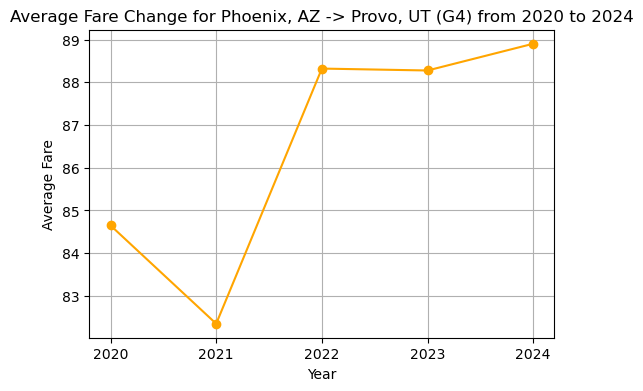

In [64]:
# Filter the data for the year 2020-2024, specific route (Phoenix, AZ -> Provo, UT), and airline 'G4'
df_2020_2024_g4_route = df[(df['year'].astype(int).isin([2020, 2021, 2022, 2023, 2024])) &
                            (df['city1'] == 'Phoenix, AZ') &
                            (df['city2'] == 'Provo, UT') &
                            (df['car'] == 'G4')]

# Calculate the average fare for each year
average_fare_per_year_g4 = df_2020_2024_g4_route.groupby('year')['mkt_fare'].mean().reset_index()

plt.figure(figsize=(6, 4))
plt.plot(average_fare_per_year_g4['year'], average_fare_per_year_g4['mkt_fare'], marker='o', color='orange')

plt.xlabel('Year')
plt.ylabel('Average Fare')
plt.title('Average Fare Change for Phoenix, AZ -> Provo, UT (G4) from 2020 to 2024')

plt.grid(True)
plt.show()

#### ***Q13: How has the average fare for airlines AA, UA, F9, AS and G4 changed from 2000 to 2024?***  

*Conclusion:*  
**AA (American Airlines)** and **UA (United Airlines)** have higher fares, and their fare trends show significant fluctuations over time. Before 2017, the fares for these two airlines were somewhat comparable. However, after 2017, AA's fares consistently remained higher than UA's.  
**G4 (Allegiant Airlines)** and **AS (Alaska Airlines)** maintain a lower fare compared to AA and UA, but it has shown a very slow and steady increase over the years.  
It is worth mentioning that before 2005, **F9 (Frontier Airlines)**'s fare positioning was similar to that of UA and AA, but after 2005, it suddenly shifted to a low-cost carrier.

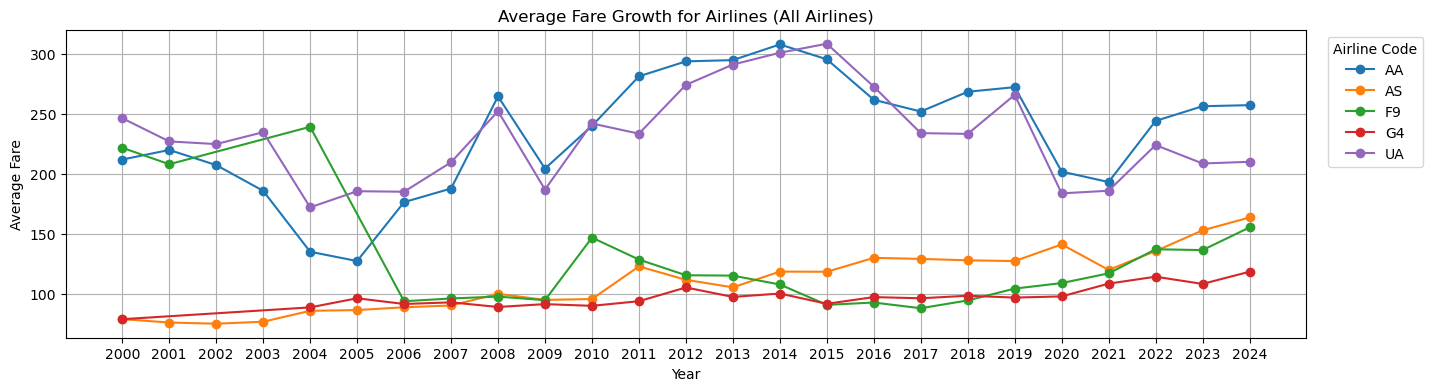

In [66]:
# Calculate the average fare for each year for all airlines
average_fare_all_airlines_per_year = df.groupby(['year', 'car'])['mkt_fare'].mean().reset_index()

plt.figure(figsize=(16, 4))

# Plot for each airline
for airline in average_fare_all_airlines_per_year['car'].unique():
    airline_data = average_fare_all_airlines_per_year[average_fare_all_airlines_per_year['car'] == airline]
    plt.plot(airline_data['year'], airline_data['mkt_fare'], marker='o', label=airline)

plt.xlabel('Year')
plt.ylabel('Average Fare')
plt.title('Average Fare Growth for Airlines (All Airlines)')

plt.legend(title="Airline Code", bbox_to_anchor=(1.1, 1), loc='upper right')
plt.grid(True)
plt.show()

#### ***Q14: How are the price categories (Low, Medium, High) distributed across different airlines?***  
  
*Conclusion:*  
- **AA** and **UA** are categorized as **high-priced airlines**.
- **AS** is considered a **medium-priced airline**.
- **F9** and **G4** are classified as **low-priced airlines**.

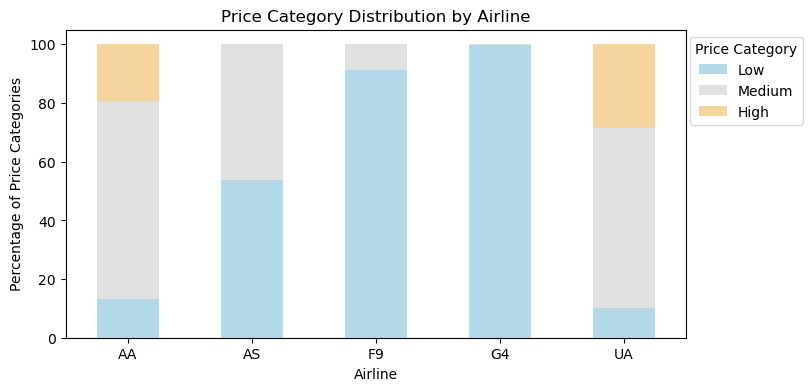

In [68]:
# Calculate the distribution of price categories for each airline (car)
price_category_distribution = df.groupby(['car', 'price_category']).size().unstack(fill_value=0)
price_category_order = ['Low', 'Medium', 'High']
price_category_distribution = price_category_distribution[price_category_order]

# Calculate the percentage of each price category within each airline
price_category_distribution_percentage = price_category_distribution.div(price_category_distribution.sum(axis=1), axis=0) * 100


price_category_distribution_percentage.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#b3d9e8', '#e1e1e1', '#F4D49D'])
plt.xlabel('Airline')
plt.ylabel('Percentage of Price Categories')
plt.title('Price Category Distribution by Airline')
plt.xticks(rotation=0)
plt.legend(title='Price Category', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.show()

#### ***Q15: What are the top 10 routes with the highest fare increase in 2024?***  

*Conclusion:*  
The **Dayton, OH -> Washington, DC (Metropolitan Area)** route (operated by **UA**) and the **Atlanta, GA (Metropolitan Area) -> Charlotte, NC** route (operated by **AA**) experienced the largest fare increases in 2024, with fares above **$500**.

In [70]:
# Sort the data by 'fareinc_max' and get the top 10 routes with the highest max fare increase
top_10_fareinc_max_routes_2024 = df_2024.sort_values(by='fareinc_max', ascending=False).head(10)

# Display the top 10 routes with the highest max fare increase
top_10_fareinc_max_routes_2024[['year', 'quarter', 'city1', 'city2', 'car', 'fareinc_max']]

,year,quarter,city1,city2,car,fareinc_max
14698,2024,2,"Dayton, OH","Washington, DC (Metropolitan Area)",UA,550
14824,2024,3,"Dayton, OH","Washington, DC (Metropolitan Area)",UA,550
14748,2024,3,"Atlanta, GA (Metropolitan Area)","Charlotte, NC",AA,525
14661,2024,2,"Atlanta, GA (Metropolitan Area)","Charlotte, NC",AA,500
14900,2024,4,"Atlanta, GA (Metropolitan Area)","Charlotte, NC",AA,500
14456,2024,1,"Atlanta, GA (Metropolitan Area)","Charlotte, NC",AA,500
14645,2024,1,"Cincinnati, OH","Philadelphia, PA",AA,500
14493,2024,1,"Dayton, OH","Washington, DC (Metropolitan Area)",AA,475
14796,2024,3,"Chicago, IL","Tulsa, OK",UA,475
14654,2024,2,"Huntsville, AL","Washington, DC (Metropolitan Area)",AA,475


#### ***Q16: What are the top 10 routes with the least fare increase in 2024?***  

*Conclusion:*  
The **top 10 routes with the least fare increase in 2024** are all characterized by a fare increase of **$75**. These routes are operated by airlines like **G4 (Allegiant Air)**, **F9 (Frontier Airlines)**, and **AA (American Airlines)**. Most of these routes show consistent, modest fare increases, with **G4** dominating the list, indicating that these routes have relatively stable pricing in 2024.

In [72]:
# Sort the data by 'fareinc_min' and get the top 10 routes with the leastest max fare increase
top_10_fareinc_min_routes_2024 = df_2024.sort_values(by='fareinc_min', ascending=False).head(10)

# Display the top 10 routes with the leastest max fare increase
top_10_fareinc_min_routes_2024[['year', 'quarter', 'city1', 'city2', 'car', 'fareinc_min']]

,year,quarter,city1,city2,car,fareinc_min
14978,2024,4,"Knoxville, TN","Sanford, FL",G4,75
14804,2024,3,"Cedar Rapids/Iowa City, IA","Denver, CO",F9,75
14666,2024,2,"Asheville, NC","Miami, FL (Metropolitan Area)",G4,75
14667,2024,2,"Phoenix, AZ","Provo, UT",G4,75
14683,2024,2,"Cedar Rapids/Iowa City, IA","Denver, CO",F9,75
14695,2024,2,"Myrtle Beach, SC","Philadelphia, PA",F9,75
14706,2024,2,"Fresno, CA","Las Vegas, NV",G4,75
14717,2024,2,"Indianapolis, IN","Philadelphia, PA",AA,75
14723,2024,2,"Los Angeles, CA (Metropolitan Area)","Provo, UT",G4,75
14726,2024,2,"Cincinnati, OH","Valparaiso, FL",G4,75


#### ***Q17: What are the average highest fare increase and average least fare increase across different airlines in 2024?***  

*Conclusion:*  
1. Average Highest Fare Increase:  
AA has the highest average fare increase, with a value significantly higher than the others.  
UA follows with a lower increase compared to AA, while the other airlines, such as F9, G4, and AS, show moderate increases, with AS being slightly higher than G4.
2. Average Least Fare Increase:  
AA again shows the highest average least fare increase, with UA coming in second place.  
The other airlines (F9, G4, AS) have similar values for the least fare increase.  

💡 If you're planning to purchase tickets from UA or AA, it's advisable to seize the opportunity while ticket prices are still low, as both airlines have significant fare increases. If the ticket price is 100–150 higher than usual, this is considered reasonable, as fares may rise to over 300 above the average in the future.   
As for the other three airlines, although their fare increases are not as pronounced, AS still shows a significantly higher increase compared to F9 and G4. Therefore, while AS's increase is smaller than UA and AA, it is still important to keep an eye on its price fluctuations.

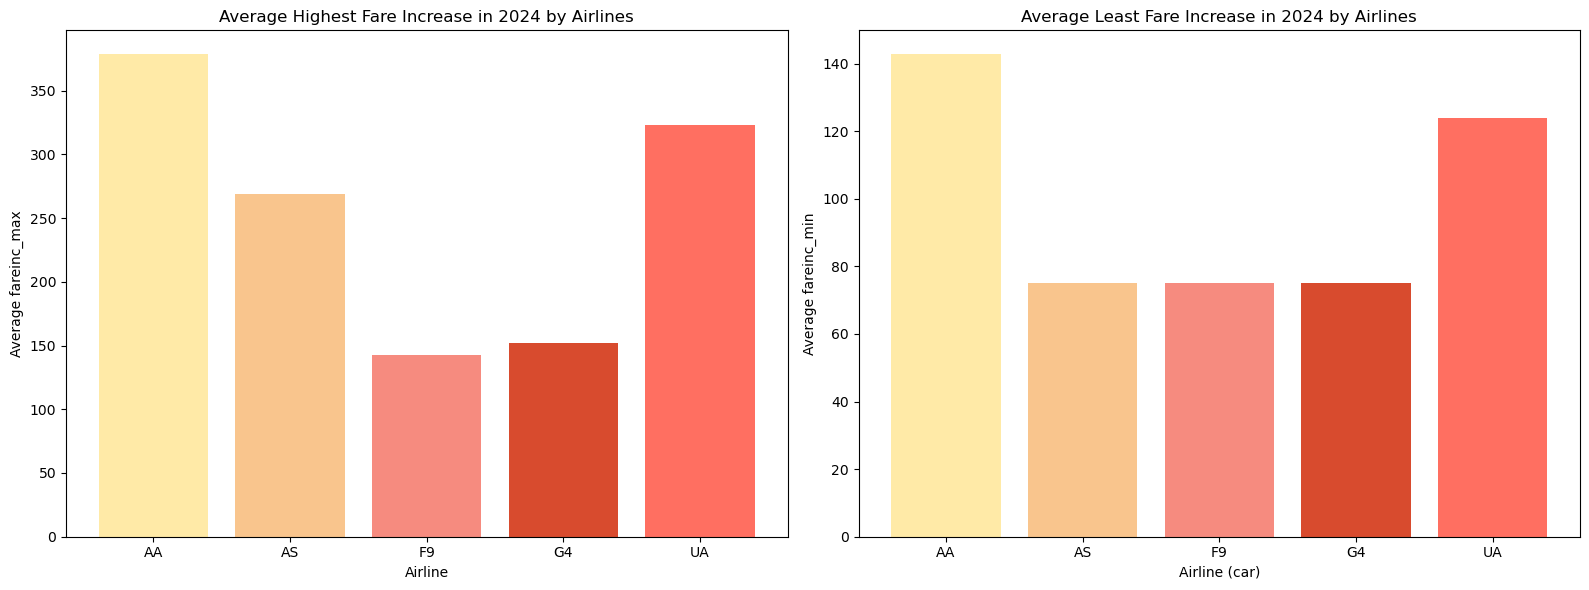

In [74]:
# Convert 'fareinc_max' to numeric, forcing errors to NaN for invalid values
df_2024.loc[:, 'fareinc_max'] = pd.to_numeric(df_2024['fareinc_max'], errors='coerce')

# Group by airline and calculate the average fareinc_max for each airline
average_fareinc_max_2024 = df_2024.groupby('car')['fareinc_max'].mean().reset_index()

# Convert 'fareinc_min' to numeric, forcing errors to NaN for invalid values
df_2024.loc[:, 'fareinc_min'] = pd.to_numeric(df_2024['fareinc_min'], errors='coerce')

# Group by airline and calculate the average fareinc_min for each airline
average_fareinc_min_2024 = df_2024.groupby('car')['fareinc_min'].mean().reset_index()

# Create two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

# Plot the average fareinc_max for 2024 on the first subplot
axes[0].bar(average_fareinc_max_2024['car'], average_fareinc_max_2024['fareinc_max'], color=['#ffeaa7', '#f9c58d', '#f68b7f', '#d84b2e', '#ff6f61'])
axes[0].set_xlabel('Airline')
axes[0].set_ylabel('Average fareinc_max')
axes[0].set_title('Average Highest Fare Increase in 2024 by Airlines')

# Plot the average fareinc_min for 2024 on the second subplot
axes[1].bar(average_fareinc_min_2024['car'], average_fareinc_min_2024['fareinc_min'], color=['#ffeaa7', '#f9c58d', '#f68b7f', '#d84b2e', '#ff6f61'])
axes[1].set_xlabel('Airline (car)')
axes[1].set_ylabel('Average fareinc_min')
axes[1].set_title('Average Least Fare Increase in 2024 by Airlines')

# Adjust layout for better spacing
plt.tight_layout()
# Display the plots
plt.show()

#### ***Q18: What is the relationship between market demand and airfare pricing level for High-Priced Airline (UA & AA)?***  

*Conclusion:*  
For **AA** (American Airlines) and **UA** (United Airlines), the pricing of tickets is significantly influenced by market demand. During periods of high demand, ticket prices tend to increase, reflecting the airlines' dynamic pricing strategies that aim to maximize revenue. Conversely, when demand is lower, airlines may lower their prices to attract more passengers and remain competitive. This price fluctuation is a common strategy employed by **premium-priced airlines**, as they adjust fares based on changing market conditions and consumer demand patterns.

/var/folders/g6/ypqsg6fx0cv23h420cpm0r7w0000gn/T/ipykernel_11388/1051541468.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aa_ua['price_category'] = pd.Categorical(df_aa_ua['price_category'], categories=price_category_order, ordered=True)


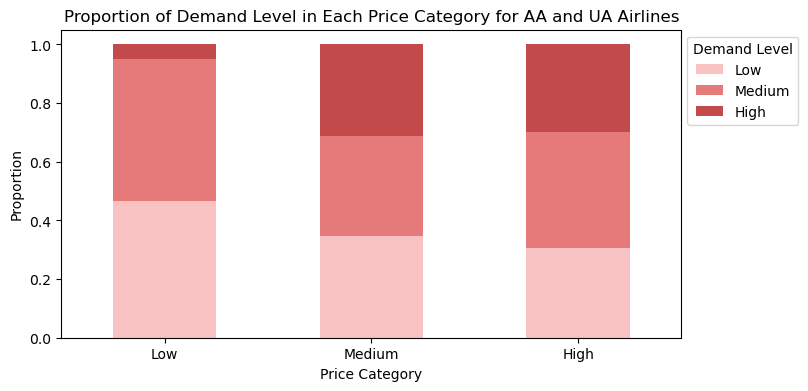

In [76]:
# Filter the data for AA and UA airlines
df_aa_ua = df[df['car'].isin(['AA', 'UA'])]

# Set the order of 'price_category' to be Low, Medium, High
price_category_order = ['Low', 'Medium', 'High']
df_aa_ua['price_category'] = pd.Categorical(df_aa_ua['price_category'], categories=price_category_order, ordered=True)

# Calculate the proportion of different demand levels within each price category
demand_level_proportion = pd.crosstab(df_aa_ua['price_category'], df_aa_ua['demand_level'], normalize='index')

# Plot the proportion chart
demand_level_proportion.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#f9c2c2', '#e67979', '#c34a4a'])

plt.xlabel('Price Category')
plt.ylabel('Proportion')
plt.title('Proportion of Demand Level in Each Price Category for AA and UA Airlines')
plt.xticks(rotation=0)
plt.legend(title='Demand Level', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.show()

#### ***Q19: What is the relationship between market demand and airfare pricing level for Low-Priced Airline (AS & F9 & G4)?***  

*Conclusion:*   
For **AS** (Alaska Airlines), **F9** (Frontier Airlines), and **G4** (Allegiant Air), the relationship between market demand and airfare pricing follows an opposite trend compared to high-priced airlines. These low-priced airlines often experience higher demand when their ticket prices are lower. As the prices are more affordable, they attract a larger volume of passengers, resulting in a higher number of tickets sold. This pricing strategy allows them to maintain high demand, even with lower fares, making air travel more accessible to a broader customer base.

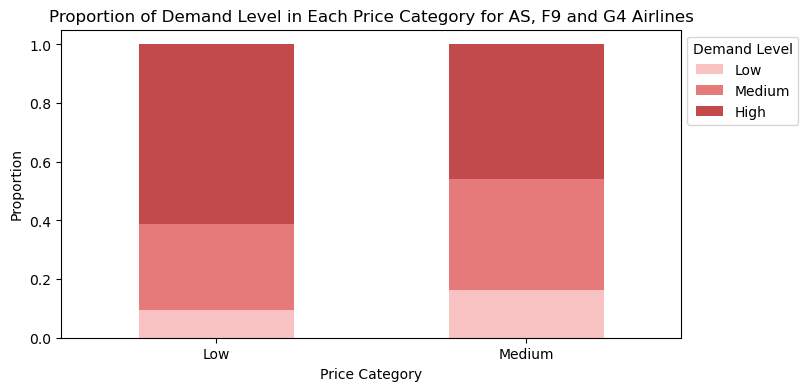

In [78]:
# Filter the data for AS, F9, and G4 airlines
df_as_f9_g4 = df[df['car'].isin(['AS', 'F9', 'G4'])]

# Set the order of 'price_category' to be Low, Medium, High
price_category_order = ['Low', 'Medium', 'High']
df_as_f9_g4.loc[:, 'price_category'] = pd.Categorical(df_as_f9_g4['price_category'], categories=price_category_order, ordered=True)

# Calculate the proportion of different demand levels within each price category
demand_level_proportion = pd.crosstab(df_as_f9_g4['price_category'], df_as_f9_g4['demand_level'], normalize='index')

# Plot the proportion chart
demand_level_proportion.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#f9c2c2', '#e67979', '#c34a4a'])

plt.xlabel('Price Category')
plt.ylabel('Proportion')
plt.title('Proportion of Demand Level in Each Price Category for AS, F9 and G4 Airlines')
plt.xticks(rotation=0)
plt.legend(title='Demand Level', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.show()

#### ***Q20: What is the correlation between demand level and flight fare for the year(2024)?***  

*Conclusion:*  
**Market Fare Range:**  
The market fare for each demand level spans a wide range, with Low demand fares clustering near the lower end of the range (below 150), Medium demand fares centered around 200-300, and High demand fares reaching up to 400.  
**Median and Distribution:**  
As the demand level increases, the distribution of market fares also shifts toward higher values, with High demand fares showing a wider spread compared to Low and Medium categories.  
**Variation in Fares:**  
The plot indicates that there is a relatively broad variation in the fares within each category, especially for High demand.

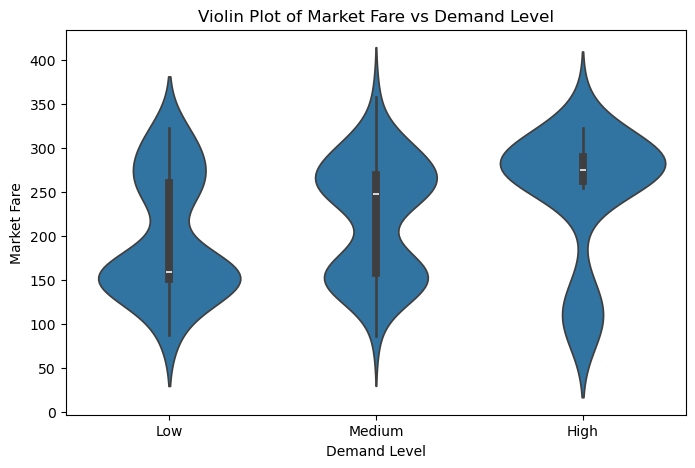

In [80]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='demand_level', y='mkt_fare', data=df_2024)
plt.title('Violin Plot of Market Fare vs Demand Level')
plt.xlabel('Demand Level')
plt.ylabel('Market Fare')
plt.show()

#### ***Q21: What is the proportion of passengers paying three times the minimum fare each year?***  

*Conclusion:*  
Looking at **2020 and 2021**, although the average ticket prices were lower in these two years, the proportion of passengers paying three times the minimum fare increased. This may be related to the special demand patterns during the pandemic and adjustments in the airlines' pricing strategies. Perhaps the services provided with the three times fare were better, and compared to previous years, the three times fare during the 2020 and 2021 pandemic period was actually a relatively cheaper option.

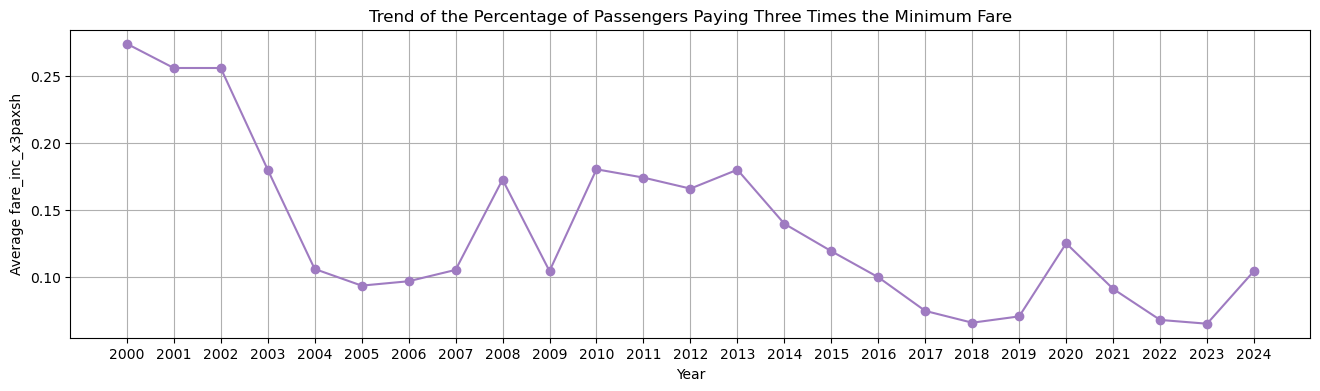

In [82]:
# Group by 'Year' and calculate the average of 'fare_inc_x3paxsh' for each year
average_fare_inc_x3paxsh_per_year = df.groupby('year')['fare_inc_x3paxsh'].mean().reset_index()

# Plot the average fare_inc_x3paxsh per year
plt.figure(figsize=(16, 4))
plt.plot(average_fare_inc_x3paxsh_per_year['year'], average_fare_inc_x3paxsh_per_year['fare_inc_x3paxsh'], marker='o', color='#9f7bc1')

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Average fare_inc_x3paxsh')
plt.title('Trend of the Percentage of Passengers Paying Three Times the Minimum Fare')

# Display the plot
plt.grid(True)
plt.show()

---

## ‼️ Summary

| **Category**        | **Airlines**                           | **Key Observations**                                                                                                                                                                |
|---------------------|----------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **High-Priced Airlines** | UA, AA                                 | - Prices are raised when demand increases **(Q18)** <br> - The top ten most expensive tickets in 2024 were sold by high-priced airlines **(Q9)** <br> - More affected during the pandemic **(Q13)** <br> - Significant price variation for high-priced airlines' routes **(Q16 & Q17)** |
| **Low-Priced Airlines** | AS (mid-range), F9, G4                 | - Lower-priced tickets sell more **(Q19)** <br> - Most of the top ten cheapest tickets in 2024 were sold by low-priced airlines (G4), with a few exceptions from UA (non-interstate routes like FL-FL & TX-TX) **(Q11)** <br> - Less affected or nearly no impact during the pandemic **(Q13)** <br> - Price increases for low-priced airlines are more stable compared to high-priced airlines **(Q16 & Q17)** |
| **Fare Trends**       | Overall Fare Changes                    | - In 2020 and 2021, ticket prices averaged lower **(Q7)**, but the proportion of passengers paying three times the minimum fare increased **(Q21)**, possibly because passengers perceived even the higher three-times fares as cheaper compared to previous years and opted for upgrades, etc. <br> - In 2024, both the most expensive and cheapest routes were influenced by the pandemic **(Q10 & Q12)** <br> - First and second quarters had the highest fares, followed by the third quarter, with the fourth quarter being the cheapest, but the difference is minimal **(Q6 & Q7)** <br>- In 2024, it can be observed that, overall, ticket prices tend to increase as demand rises **(Q20)**|
